In [1]:
## Imports ##
from pathlib import Path
from scipy.spatial.transform import Rotation
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from xacrodoc import XacroDoc
from pytransform3d.urdf import UrdfTransformManager

In [2]:
## Definitions ##
MINS_OUTPUT_BASE_PATH = \
    '/home/libonati/Documents/dataset_rosariov2/mins/'
DATASET_SESSIONS = [
    '2023-12-22-13-14-16',
    #'2023-12-22-14-29-43', '2023-12-22-16-31-08',
    #'2023-12-26-13-39-43', '2023-12-26-15-10-15', '2023-12-26-15-48-38'
]

MINS_OUTPUT_NAME_FORMAT = '{}_mins_tum.csv'

MINS_OUTPUT_COLUMNS = ['timestamp', 'tx', 'ty', 'tz', 'qx', 'qy', 'qz', 'qw']

In [3]:
# Read in file
ground_truth_paths = []
for dataset_session in DATASET_SESSIONS:
    gt_path = f'{MINS_OUTPUT_BASE_PATH}'+MINS_OUTPUT_NAME_FORMAT.format(dataset_session)
    ground_truth_paths.append(gt_path)
print(*ground_truth_paths, sep='\n')

gt_data = pd.read_csv(
    ground_truth_paths[0], sep=' ', header=None, names=MINS_OUTPUT_COLUMNS)

print(gt_data)

/home/libonati/Documents/dataset_rosariov2/mins/2023-12-22-13-14-16_mins_tum.csv
         timestamp        tx        ty        tz        qx        qy  \
0     1.703262e+09 -0.004968 -0.003906  0.003764 -0.813162 -0.001252   
1     1.703262e+09 -0.004998  0.004367  0.006217 -0.812837 -0.000923   
2     1.703262e+09 -0.005554  0.013442  0.006977 -0.812549 -0.001057   
3     1.703262e+09 -0.006778  0.061402  0.008188 -0.812427 -0.001019   
4     1.703262e+09  0.326512  0.411635 -0.162961 -0.575789  0.573524   
...            ...       ...       ...       ...       ...       ...   
8978  1.703263e+09  0.249570  0.252718 -0.178954 -0.561083  0.584360   
8979  1.703263e+09  0.249559  0.251659 -0.178811 -0.560927  0.584453   
8980  1.703263e+09  0.248620  0.250668 -0.178823 -0.561043  0.584330   
8981  1.703263e+09  0.248873  0.250176 -0.178883 -0.560971  0.584395   
8982  1.703263e+09  0.247641  0.248486 -0.179502 -0.560985  0.584375   

            qz        qw  
0    -0.002396  0.582032  


In [4]:
doc = XacroDoc.from_file("../data/config/rosario_v2.urdf.xacro")
urdf_str = doc.to_urdf_string()
utm = UrdfTransformManager()
utm.load_urdf(urdf_str)

In [7]:
print("T_baselink_imu_xacro: \n", utm.get_transform("base_link", "realsense_imu"))

T_baselink_imu_xacro: 
 [[ 6.56342874e-04 -9.99992239e-01  3.88475703e-03  7.59575094e-03]
 [-3.13776677e-01 -3.89450870e-03 -9.49488825e-01  1.78252115e+00]
 [ 9.49496586e-01 -5.95755928e-04 -3.13776798e-01 -1.57067022e+00]
 [ 0.00000000e+00  0.00000000e+00  0.00000000e+00  1.00000000e+00]]


In [ ]:
T_baselink_imu_xacro = utm.get_transform("base_link", "realsense_imu")
# print("T_baselink_imu_xacro: \n", T_baselink_imu_xacro)

for i,row in gt_data.iterrows():
    R_imu = Rotation.from_quat([row['qx'], row['qy'], row['qz'], row['qw']]).as_matrix()
    t_imu = np.array([[row['tx'], row['ty'], row['tz']]])
    T_imu = np.vstack((np.hstack((R_imu, t_imu.T)), [0, 0, 0, 1]))

    # T_baselink = T_imu @ T_imu_baselink
    T_baselink = T_imu @ T_baselink_imu_xacro
    q_baselink = Rotation.from_matrix(T_baselink[0:3, 0:3]).as_quat()
    t_baselink = T_baselink[0:3, 3]

    gt_data.iloc[i, 1:4] = t_baselink
    gt_data.iloc[i, 4:] = q_baselink

# Calculate yaw
gt_data['yaw'] = np.arctan2(
    2.0 * (gt_data['qw'] * gt_data['qz'] - gt_data['qx'] * gt_data['qy']),
    1.0 - 2.0 * (gt_data['qy']**2 + gt_data['qz']**2))

# downsample
gt_data = gt_data.iloc[::10, :]

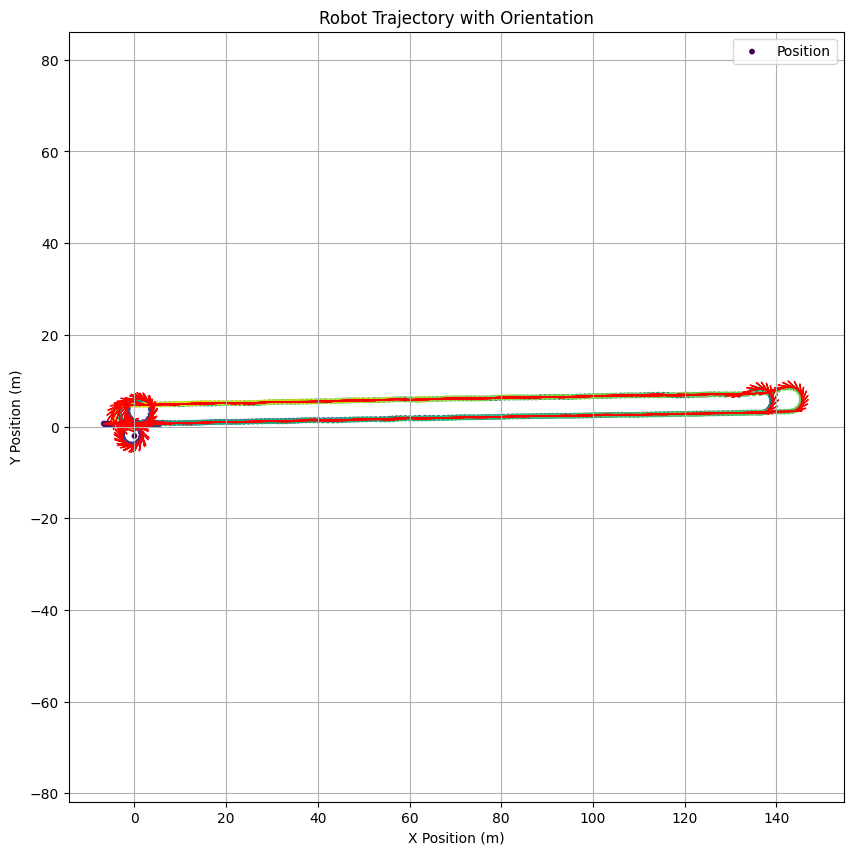

In [9]:
# Plot trajectory and orientation
timestamps = gt_data['timestamp']
norm = plt.Normalize(timestamps.min(), timestamps.max())
colors = plt.cm.viridis(norm(timestamps))  # Using the 'viridis' colormap

plt.figure(figsize=(10, 10))
plt.scatter(gt_data['tx'], gt_data['ty'], color=colors, s=10, label='Position')

arrow_length = 3
for i, row in gt_data.iterrows():
    dx = arrow_length * np.cos(row['yaw'])
    dy = arrow_length * np.sin(row['yaw'])
    plt.arrow(
        row['tx'], row['ty'], dx, dy, 
        head_width=0, head_length=0,
        fc='r', ec='r')


# Labels and legend
plt.xlabel("X Position (m)")
plt.ylabel("Y Position (m)")
plt.title("Robot Trajectory with Orientation")
plt.legend()
plt.axis("equal")
plt.grid()
plt.show()

In [ ]:
import plotly.graph_objects as go
import numpy as np

gt_copy = gt_data

def floatsec_to_time(ft):
    ft = ft - gt_data['timestamp'].iloc[0]
    int_sec = int(ft)
    return "sec:" + str(int_sec)

time_offset = gt_copy['timestamp'].map(floatsec_to_time) # To display the timestamp on the hover text

tickvals = [
    gt_data['timestamp'].iloc[0],
    gt_data['timestamp'].iloc[len(gt_data['timestamp'])//4],
    gt_data['timestamp'].iloc[len(gt_data['timestamp'])//2],
    gt_data['timestamp'].iloc[len(gt_data['timestamp'])*3//4],
    gt_data['timestamp'].iloc[-1]
]
ticktext = [floatsec_to_time(t) for t in tickvals] # To display the timestamp on the color bar

# Create 3D plot
fig = go.Figure(data=[go.Scatter3d(
    x=gt_data['tx'], y=gt_data['ty'], z=gt_data['tz'],
    mode='lines+markers',
    marker=dict(
        size=4,
        color=gt_data['timestamp'],
        colorscale='Viridis', 
        showscale=True,
        colorbar=dict(
            title="Time from start",
            tickvals=tickvals,
            ticktext=ticktext,
            tickmode="array"
        )
    ),
    line=dict(color='darkblue', width=2),
    text=time_offset
)])

# Update layout for better visualization
fig.update_layout(
    scene=dict(
        xaxis_title='X Path',
        yaxis_title='Y Path',
        zaxis_title='Z Path',
        aspectmode='data', # Scale the axis equally
    ),
    title="Robot 3D Trajectory"
)
fig.show()

In [12]:
# HTML to show the plot on the rosariov2 page
if not Path("gt_exploration_plot.html").exists:
    print("Creating HTML")
    fig.write_html("gt_exploration_plot.html")